# Exploratory Data Analysis (EDA)

In this notebook, we'll perform Exploratory Data Analysis (EDA) to understand the distribution of variables, identify patterns, analyze relationships between features, and gain insights into factors affecting mental health.

### Import Required Libraries

In [2]:
# Importing Essential Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

# Display plots inside the notebook
%matplotlib inline

In [3]:
# Loading the Dataset

df = pd.read_csv("../Data/Cleaned/Student Social Media And Mental Health Impact Cleaned Data.csv")

In [4]:
# Displying the number of rows and columns in the dataset
df.shape

(4998, 13)

In [5]:
# Displaying the first few rows of the dataset
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


# Univariate Analysis
it is the study of a **single variable** to describe its data and find its patterns.

So, We'll analyze one variable at a time.

The recommended order is:

- Age
- Gender
- Academic Level
- Most Used Platform
- Purpose of Use
- Average Daily Usage Hours
- Daily Unlocks
- Study Hours
- Physical Activity Hours
- Sleep Hours Per Night
- Stress Level
- Mental Health Score (Target)

## Univariate Analysis: Age

This analysis examines the distribution of students' ages in the dataset.

In [6]:
# Display summary statistics for the Age column
df['Age'].describe()

count    4998.000000
mean       20.822129
std         1.736774
min        18.000000
25%        19.000000
50%        21.000000
75%        22.000000
max        24.000000
Name: Age, dtype: float64

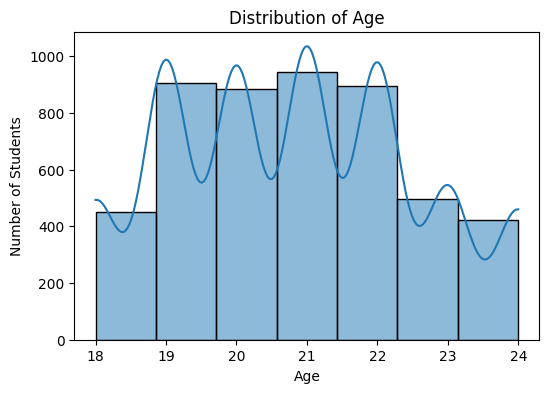

In [7]:
# Plot the distribution of Age

plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=7, kde=True)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Number of Students")

plt.show()

### Observation

- The age of students ranges from **18 to 24 years**.
- The distribution shows that most students are between **19 and 22 years old**.
- The age values are fairly balanced with no major outliers.

## Univariate Analysis: Gender

This analysis examines the distribution of students based on gender

In [8]:
# Display the count of each gender category
df['Gender'].value_counts()

Gender
Male      2634
Female    2364
Name: count, dtype: int64

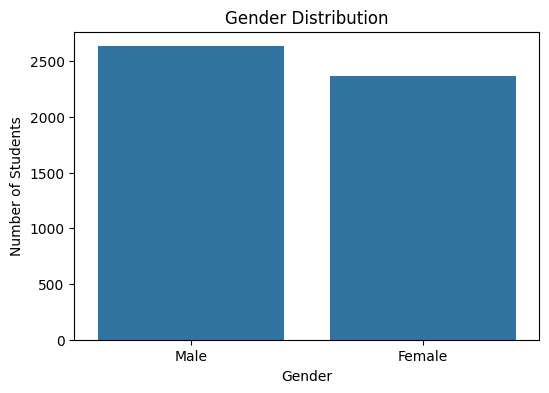

In [9]:
# Plot the distribution of students based on gender

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Gender')

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Students")

plt.show()

### Observation

- The dataset contains **2634 male students and 2364 female students**.
- The gender distribution is relatively balanced.
- No major imbalance is observed between the gender categories.

## Univariate Analysis: Academic Level

This analysis examines the distribution of students across different academic levels.

In [10]:
# Display the count of each academic level

df['Academic_Level'].value_counts()

Academic_Level
Undergraduate    3630
Graduate          918
High School       450
Name: count, dtype: int64

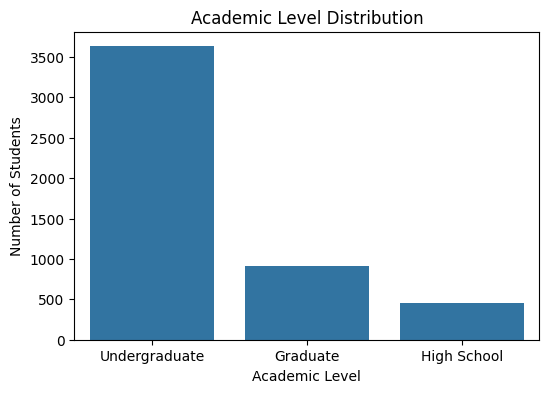

In [21]:
# Plot the distribution of academic levels

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Academic_Level')

plt.title("Academic Level Distribution")
plt.xlabel("Academic Level")
plt.ylabel("Number of Students")

plt.show()

### Observation

- Undergraduate students make up the largest portion of the dataset.
- Graduate students are fewer than undergraduate students.
- High school students represent the smallest group.

## Univariate Analysis: Most Used Platform

This analysis examines the distribution of the most frequently used social media platforms.

In [22]:
# Display the count of each social media platform

df['Most_Used_Platform'].value_counts()

Most_Used_Platform
Instagram    1130
TikTok        918
Facebook      719
LinkedIn      522
YouTube       491
Twitter       462
Snapchat      419
WhatsApp      175
LINE           50
VKontakte      40
KakaoTalk      36
WeChat         36
Name: count, dtype: int64

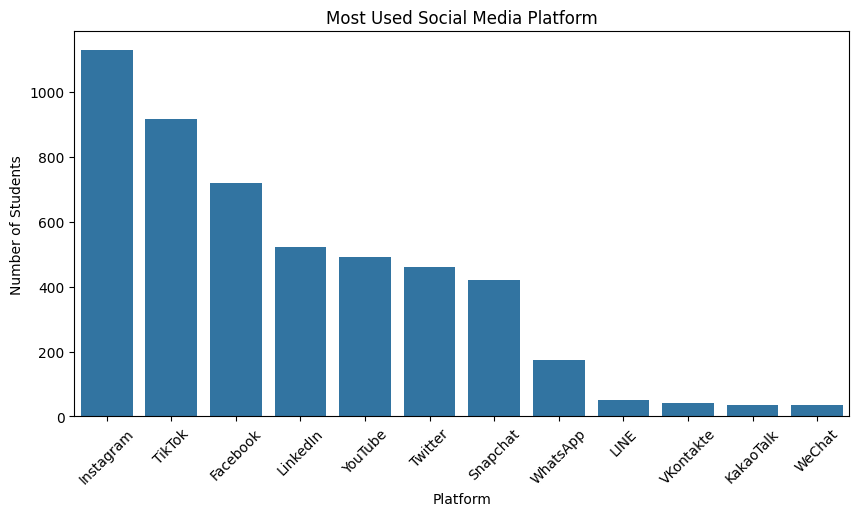

In [23]:
# Plot the distribution of the most used social media platforms

plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    x='Most_Used_Platform',
    order=df['Most_Used_Platform'].value_counts().index
)

plt.title("Most Used Social Media Platform")
plt.xlabel("Platform")
plt.ylabel("Number of Students")
plt.xticks(rotation=45)

plt.show()

### Observation

- **Instagram** is the most frequently used social media platform among students.
- **TikTok** and **Facebook** are also widely used.
- Platforms like **LINE, VKontakte, KakaoTalk, and WeChat** have the lowest usage.

## Univariate Analysis: Average Daily Usage Hours

This analysis examines the distribution of students' average daily social media usage.

### Distribution of the target (Mental_Health_Score)

Before predicting anything, we need to understand the shape of what we're predicting.

<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

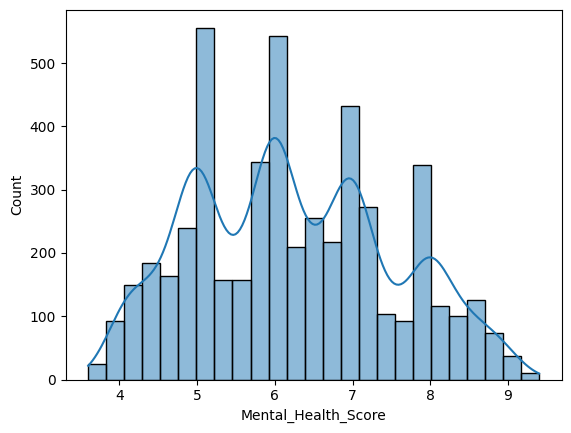

In [11]:
sns.histplot(df["Mental_Health_Score"],kde=True)

#### 3.2 Correlation heatmap

Which numeric features actually moves together with the target?

<Axes: >

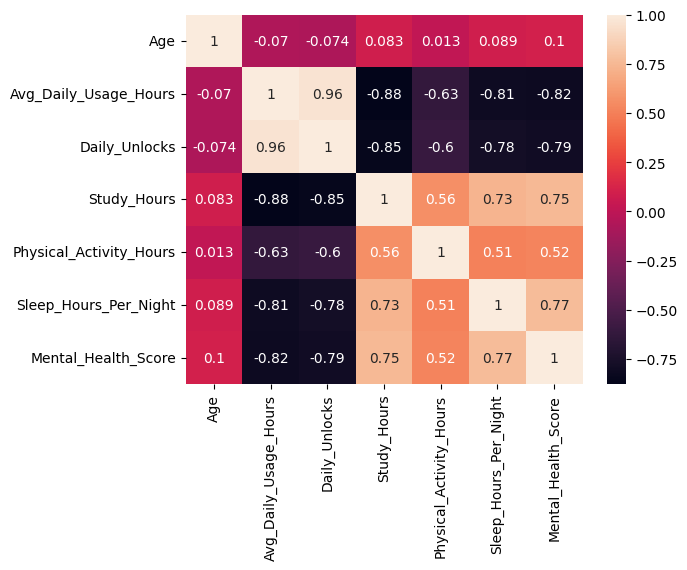

In [12]:
sns.heatmap(df.corr(numeric_only = True),annot=True)

#### 3.3 Stress Level VS Mental Health Score

Does higher stress genuinely come with a lower score?


In [13]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='str')

In [14]:
df['Stress_Level'].unique()

<ArrowStringArray>
['Medium', 'Low', 'Very High', 'High']
Length: 4, dtype: str

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

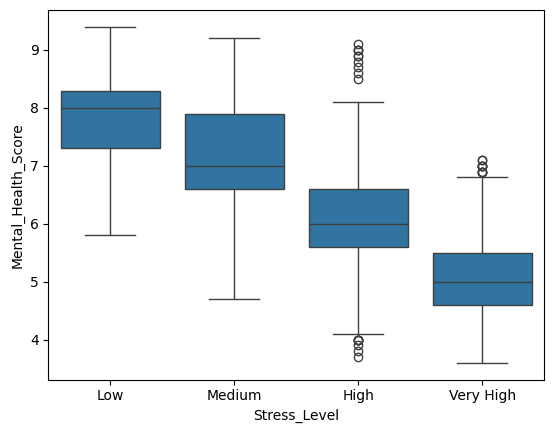

In [15]:
order = ['Low','Medium','High','Very High']
sns.boxplot(x='Stress_Level',y='Mental_Health_Score',data=df,order=order)

#### 3.4 Daily Usage Hours vs Mental Health Score

Does more time on social media realte to a lower score?

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

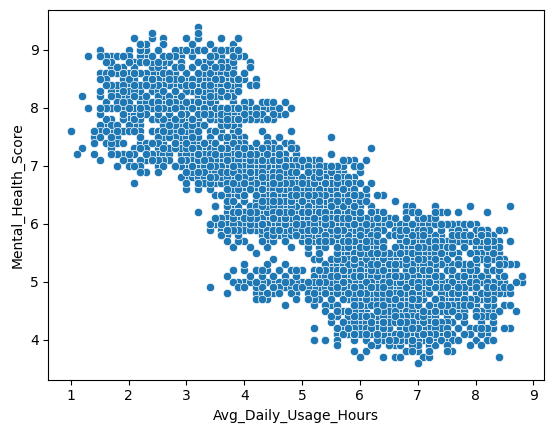

In [16]:
sns.scatterplot(x='Avg_Daily_Usage_Hours', y='Mental_Health_Score',data = df)

#### 3.5 Sleep Hours vs Mental Health Score

Sleep is one of the most commonly cited mental health factors -- does the data back that up?

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

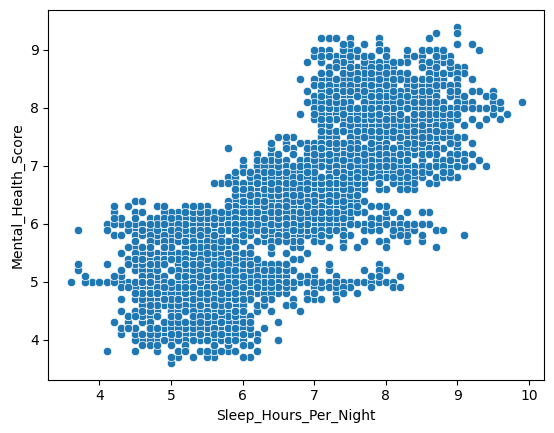

In [17]:
sns.scatterplot(x='Sleep_Hours_Per_Night', y='Mental_Health_Score',data = df)

#### 3.6 Most Used Platform (Count)

A quick at which platforms are most common in our dataset.

In [18]:
df['Most_Used_Platform'].value_counts()

Most_Used_Platform
Instagram    1130
TikTok        918
Facebook      719
LinkedIn      522
YouTube       491
Twitter       462
Snapchat      419
WhatsApp      175
LINE           50
VKontakte      40
KakaoTalk      36
WeChat         36
Name: count, dtype: int64

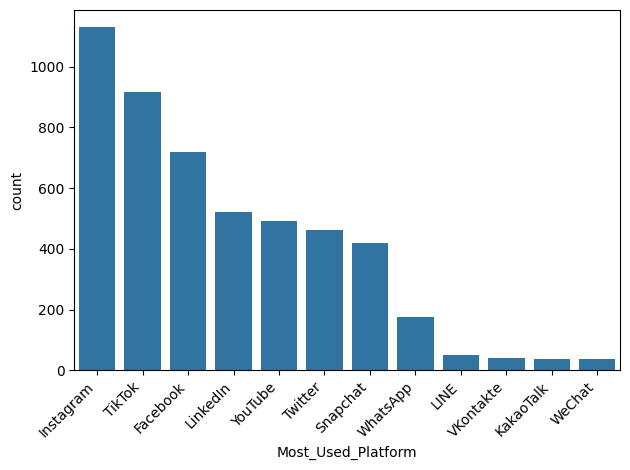

In [19]:
sns.countplot(x='Most_Used_Platform', data=df, order=df['Most_Used_Platform'].value_counts().index)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

### Checking Outliers:

In [20]:
num_features = df.select_dtypes(include='number') # int64 or float64

Q1 = num_features.quantile(0.25)
Q3 = num_features.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (num_features < lower_bound) | (num_features > upper_bound)
outlier_counts = outliers.sum()
outlier_counts

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    12
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64